$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.26

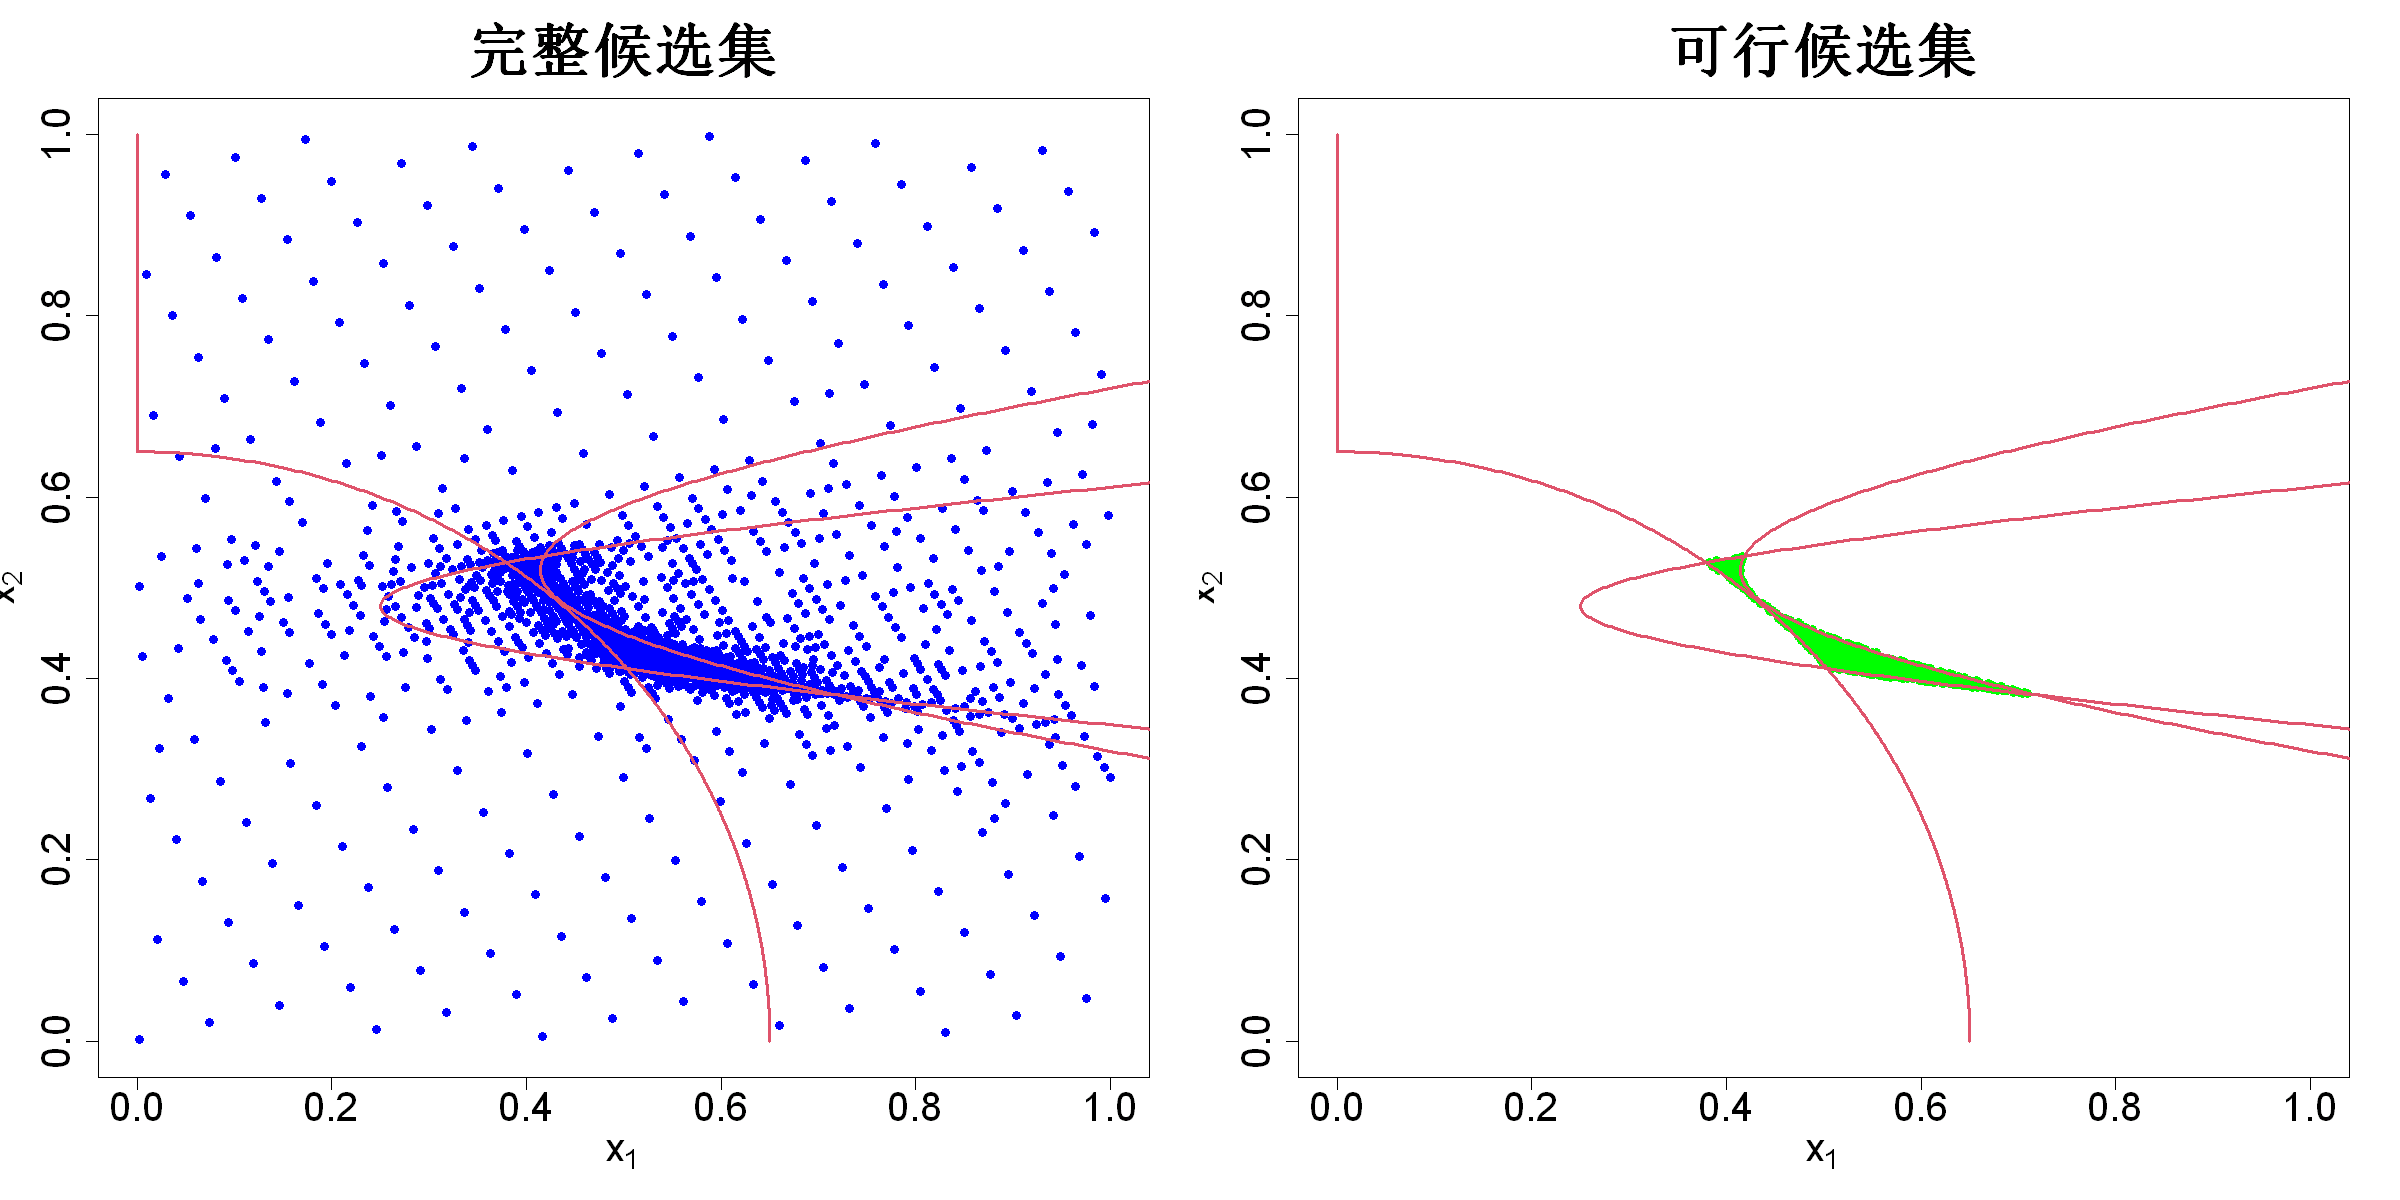

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

我们再次考察约束条件

$$\begin{align*}&g_{1}(x)=x_{1}-\sqrt{50(x_{2}-0.52)^2+2}+1\le0,\\&g_{2}(x)=\sqrt{120\left((x_{2}-0.48)^2+1\right)}-0.75-x_{1}\le0,\\&g_{3}(x)=0.65^{2}-x_{1}^2-x_{2}^2\le0,\\&\text{其中}\;0\le x_{1},x_{2}\le1\end{align*}$$

图4.26左图展示了采用上述算法,取$T=8$生成的2155个样本点,本次采样目标是构建一个53轮试验的最大投影设计;右图是其中915个可行候选点.可行点占比为$915\div2155\times100\%=42.5\%$;与之对比,此前采用一万个拉丁超立方样本得到的可行点占比仅为$538\div10000\times100\%=5.4\%$.一旦约束条件的计算成本很高,该方法将体现出巨大优势.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建画布宽20英寸,高10英寸.将画布分为`1x2`.依据

$$\begin{align*}&g_{1}(x)=x_{1}-\sqrt{50(x_{2}-0.52)^2+2}+1\le0,\\&g_{2}(x)=\sqrt{120\left((x_{2}-0.48)^2+1\right)}-0.75-x_{1}\le0,\\&g_{3}(x)=0.65^{2}-x_{1}^2-x_{2}^2\le0,\\&\text{其中}\;0\le x_{1},x_{2}\le1\end{align*}$$

定义约束条件函数`constraint(x)`.创建`3x1001`的两个矩阵`x1`,`x2`分别储存三个约束条件的等高线数据.创建列表`contour`,储存两个矩阵.设置种子为`1`.定义约束严苛度序列`tau`,其中

$$\rho_{\tau}=(0,e,\dots,e^{7},10^{6})$$

使用`comined`包中的`comined.output`函数实现约束最小能量设计算法,其中目标设计点数为`53`,维数为`2`,约束严苛度参数序列为`tau`,约束函数为`constraint`,设计点的扩充倍数为`5`,不自动缩放约束值,使用欧氏距离`s=2`,将返回列表令为`comined.output`.取其`cand`列作为全部候选点矩阵,令其为`cand`.从`cand`中筛选可行候选点矩阵,令其为`cand.feasible`.

```r
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
constraint=function(x){
    c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
    c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
    c3=(0.65^2-x[1]^2-x[2]^2)
    return(c(c1,c2,c3))
}
x1=x2=matrix(NA,nrow=3,ncol=1001)
x2.seq=seq(0,1,length.out=1001)
x2[1,]=x2.seq
x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
x2[2,]=x2.seq
x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
x2[3,]=x2.seq
x1[3,]=sqrt(pmax(0,0.65^2-x2.seq^2))
contour=list(x1=x1,x2=x2)
set.seed(1)
tau=c(0,exp(c(1:7)),1e6)
library(comined)
comined.output=comined(n=53,p=2,tau=tau,constraint=constraint,n.aug=5,auto.scale=F,s=2)
cand=comined.output$cand
cand.feasible=comined.output$cand[comined.output$feasible.idx,]
```

绘制候选点矩阵`cand`散点图,其中点的颜色为蓝色,形状为`16`,$x$,$y$的显示范围均为`c(0,1)`,大小为`2`,$x$,$y$的标签分别为`expression(x[1])`,`expression(x[2])`,大小为`2`,标题为`完整候选集`,大小为`3`.绘制可行候选点矩阵`cand.feasible`散点图,余同上,只是点的颜色为绿色,标题为`可行候选集`.将画布还原回`1x1`.

```r
plot(cand,col="blue",pch=16,xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="完整候选集",cex.main=3)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],col=2,lwd=3)
plot(cand.feasible,col="green",pch=16,xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="可行候选集",cex.main=3)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],col=2,lwd=3)
par(mfrow=c(1,1))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

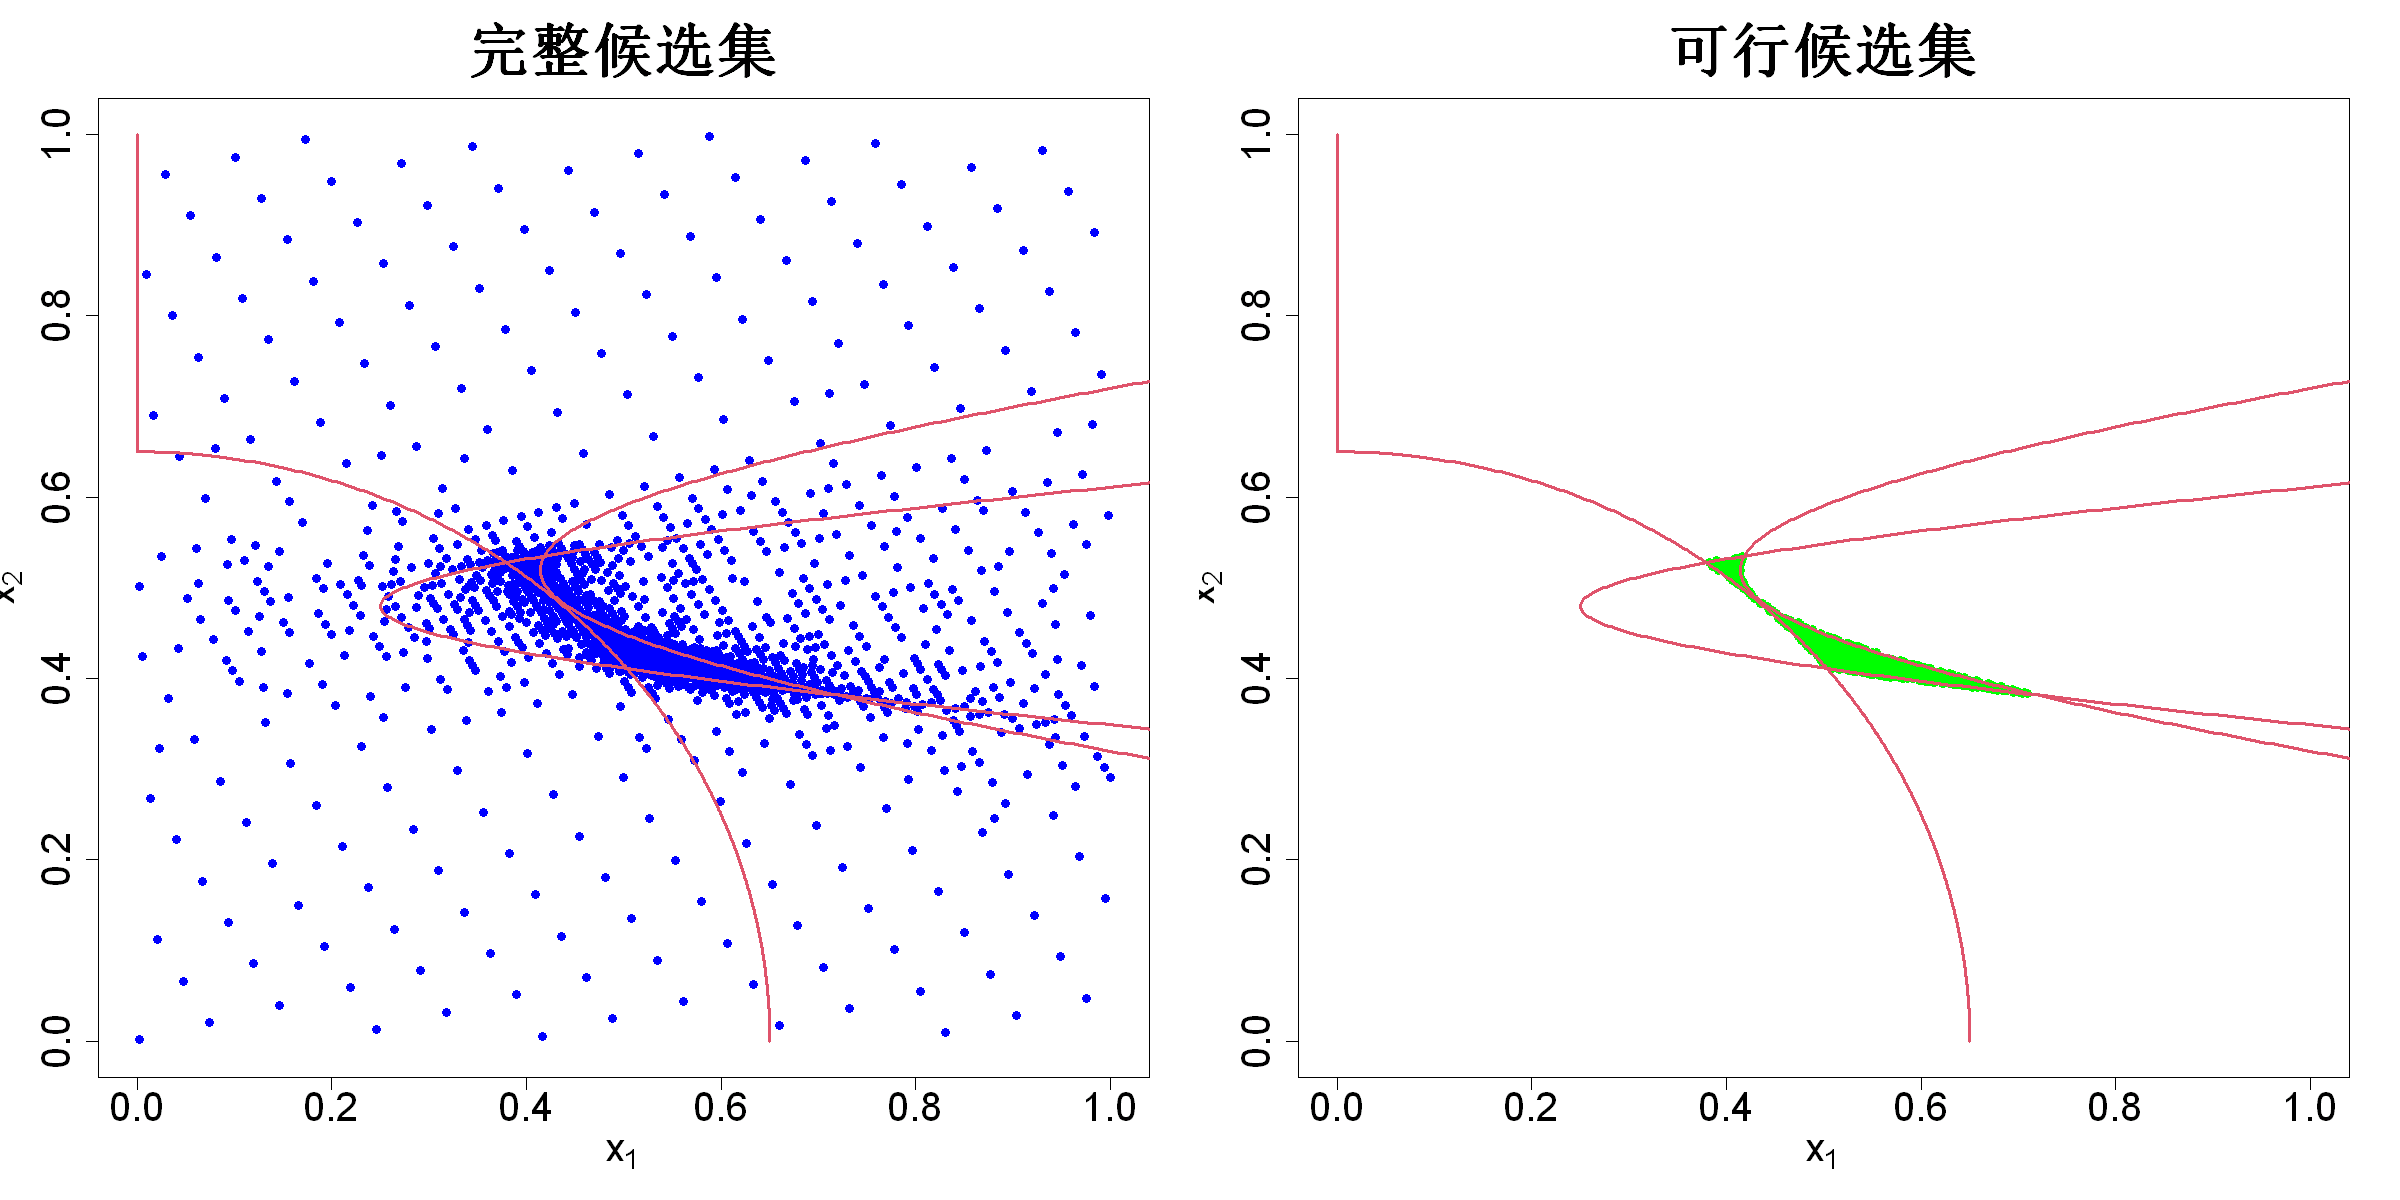

In [1]:
#图4.26

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
constraint=function(x){
    c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
    c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
    c3=(0.65^2-x[1]^2-x[2]^2)
    return(c(c1,c2,c3))
}
x1=x2=matrix(NA,nrow=3,ncol=1001)
x2.seq=seq(0,1,length.out=1001)
x2[1,]=x2.seq
x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
x2[2,]=x2.seq
x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
x2[3,]=x2.seq
x1[3,]=sqrt(pmax(0,0.65^2-x2.seq^2))
contour=list(x1=x1,x2=x2)
set.seed(1)
tau=c(0,exp(c(1:7)),1e6)
library(comined)
comined.output=comined(n=53,p=2,tau=tau,constraint=constraint,n.aug=5,auto.scale=F,s=2)
cand=comined.output$cand
cand.feasible=comined.output$cand[comined.output$feasible.idx,]

plot(cand,col="blue",pch=16,xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="完整候选集",cex.main=3)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],col=2,lwd=3)
plot(cand.feasible,col="green",pch=16,xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="可行候选集",cex.main=3)
for(i in 1:3)lines(contour$x1[i,],contour$x2[i,],col=2,lwd=3)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$